COMPARATIVE MODEL ANALYSIS

📊 Data Split Information:
Training samples: 7980
Testing samples: 1996
Sequence length: 24
Number of features: 8

🟢 MODEL 1: SIMPLE RNN
Training Simple RNN...

📈 Simple RNN Performance:
MAE: 66.86 MB
RMSE: 85.90 MB
R² Score: 0.7390

🟡 MODEL 2: GRU (Gated Recurrent Unit)
Training GRU...

📈 GRU Performance:
MAE: 69.41 MB
RMSE: 90.73 MB
R² Score: 0.7088

🔵 MODEL 3: LSTM (Long Short-Term Memory)
Training LSTM...

📈 LSTM Performance:
MAE: 119.23 MB
RMSE: 144.82 MB
R² Score: 0.2583

🟠 MODEL 4: ARIMA (Auto-Regressive Integrated Moving Average)

Augmented Dickey-Fuller Test for Original Traffic Load:
ADF Statistic: -3.5052
p-value: 0.0079
Critical Values:
	1%: -3.4312
	5%: -2.8619
	10%: -2.5670
✓ Series is stationary

Training ARIMA(5,0,0) model...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 8000
Model:                 ARIMA(5, 0, 0)   Log Likelihood         

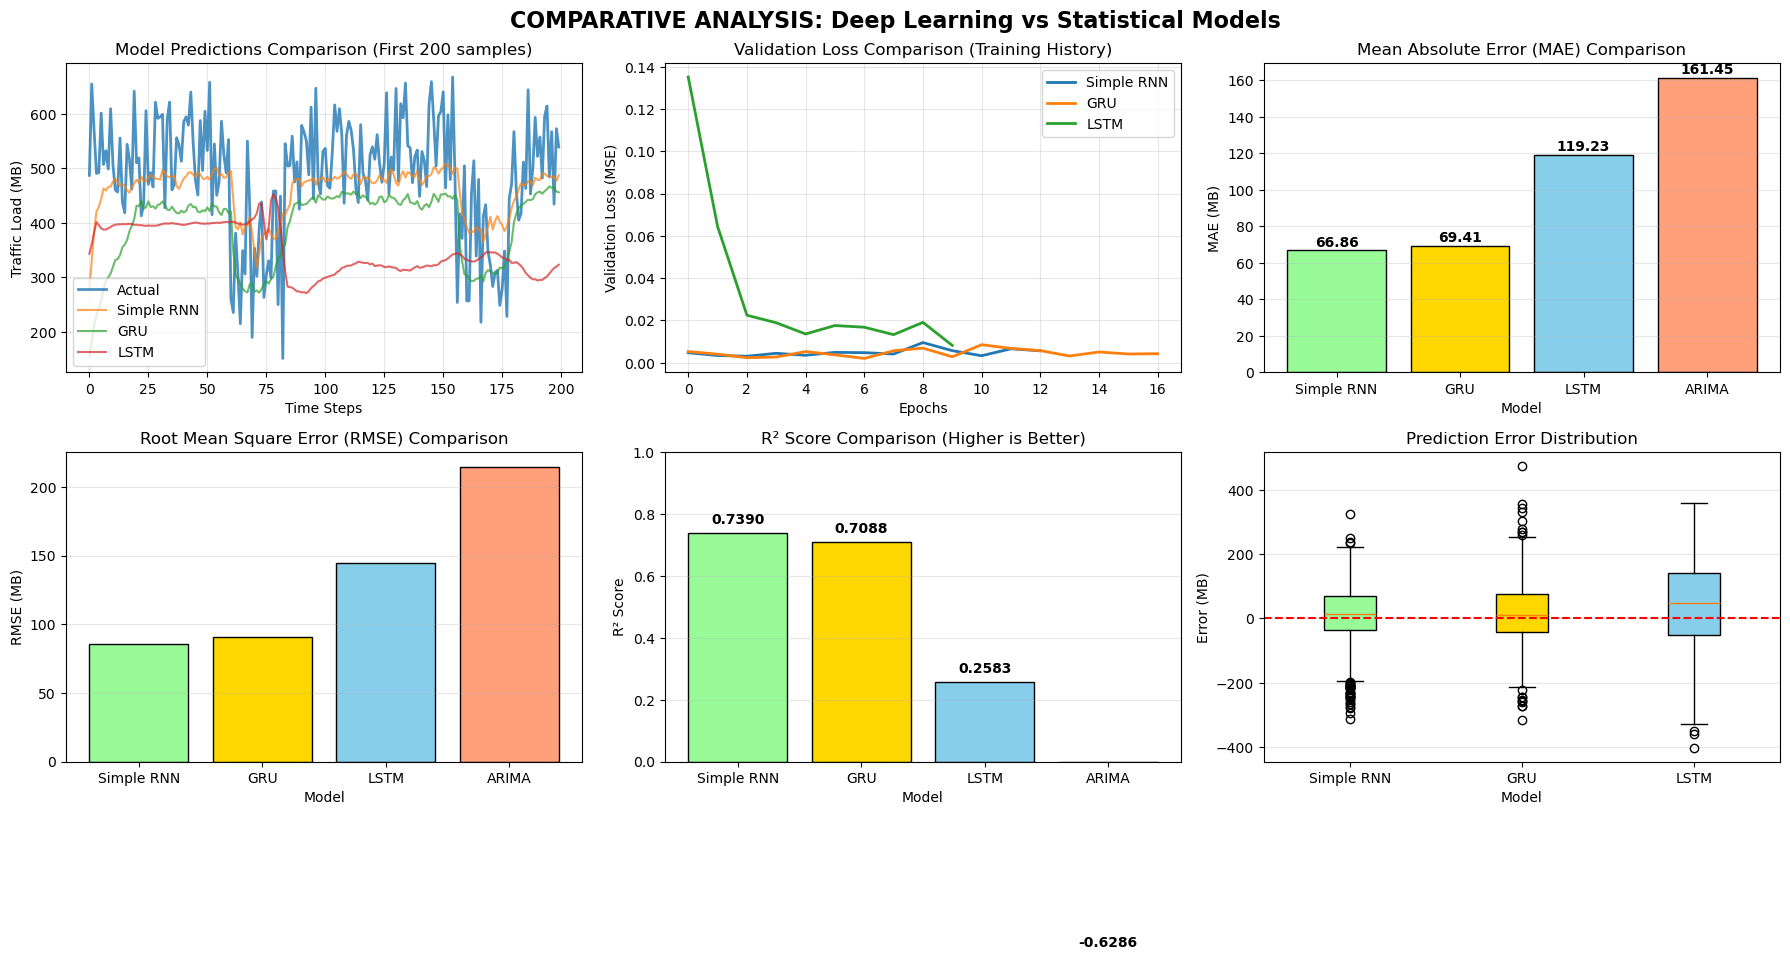


🏆 MODEL PERFORMANCE RANKING

Ranking by MAE (Lower is better):
 Rank      Model   MAE (MB)  R² Score
    1 Simple RNN  66.855944  0.739026
    2        GRU  69.412143  0.708846
    3       LSTM 119.227695  0.258273
    4      ARIMA 161.451152 -0.628611

📈 Best Model: Simple RNN with MAE = 66.86 MB
Note: Simple RNN outperforms LSTM by 43.9%

📝 SUMMARY AND RECOMMENDATIONS

Key Findings:
-------------
1. LSTM - Best for complex temporal patterns with long-term dependencies
2. GRU - Similar to LSTM but faster training (fewer parameters)
3. Simple RNN - Good for short-term patterns but suffers from vanishing gradients
4. ARIMA - Works well for stationary series but struggles with non-linear patterns

Recommendations:
----------------
✅ For Real-time Network Optimization: Use GRU (balance of accuracy and speed)
✅ For High Accuracy Requirements: Use LSTM (best overall performance)
✅ For Baseline Comparison: Use Simple RNN
✅ For Traditional Statistical Approach: Use ARIMA with proper preproce

In [1]:
# ============================================
# COMPARATIVE ANALYSIS: LSTM vs ARIMA vs GRU vs Simple RNN
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv("G://Project//Data_Processing//4g_LSTM_network_data.csv")
print("="*80)
print("COMPARATIVE MODEL ANALYSIS")
print("="*80)

# ============================================
# 1. DATA PREPARATION (Common for all models)
# ============================================

# Select features and target
features = ['hour', 'day_of_week', 'is_weekend', 'week_of_month', 'season', 
            'cell_capacity_mb', 'user_activity', 'network_utilization_pct']
target = 'traffic_load_mb'

# Normalize the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

# Create sequences for deep learning models
def create_sequences(X, y, sequence_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - sequence_length):
        X_seq.append(X[i:i + sequence_length])
        y_seq.append(y[i + sequence_length])
    return np.array(X_seq), np.array(y_seq)

sequence_length = 24
X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)

# Split into train/test sets
split_idx = int(len(X_seq) * 0.8)
X_train = X_seq[:split_idx]
X_test = X_seq[split_idx:]
y_train = y_seq[:split_idx]
y_test = y_seq[split_idx:]

print(f"\n📊 Data Split Information:")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Sequence length: {sequence_length}")
print(f"Number of features: {X_train.shape[2]}")

# For ARIMA (needs 1D time series)
traffic_series = df[target].values
train_size = int(len(traffic_series) * 0.8)
train_series = traffic_series[:train_size]
test_series = traffic_series[train_size:]

# ============================================
# 2. MODEL 1: SIMPLE RNN
# ============================================

print("\n" + "="*80)
print("🟢 MODEL 1: SIMPLE RNN")
print("="*80)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Build Simple RNN model
rnn_model = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])),
    Dropout(0.2),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train Simple RNN
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Simple RNN...")
rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_rnn_scaled = rnn_model.predict(X_test, verbose=0)
y_pred_rnn = scaler_y.inverse_transform(y_pred_rnn_scaled)
y_actual = scaler_y.inverse_transform(y_test)

# Evaluate Simple RNN
mae_rnn = mean_absolute_error(y_actual, y_pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(y_actual, y_pred_rnn))
r2_rnn = r2_score(y_actual, y_pred_rnn)

print(f"\n📈 Simple RNN Performance:")
print(f"MAE: {mae_rnn:.2f} MB")
print(f"RMSE: {rmse_rnn:.2f} MB")
print(f"R² Score: {r2_rnn:.4f}")

# ============================================
# 3. MODEL 2: GRU (Gated Recurrent Unit)
# ============================================

print("\n" + "="*80)
print("🟡 MODEL 2: GRU (Gated Recurrent Unit)")
print("="*80)

from tensorflow.keras.layers import GRU

# Build GRU model
gru_model = Sequential([
    GRU(128, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])),
    Dropout(0.2),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training GRU...")
gru_history = gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_gru_scaled = gru_model.predict(X_test, verbose=0)
y_pred_gru = scaler_y.inverse_transform(y_pred_gru_scaled)

# Evaluate GRU
mae_gru = mean_absolute_error(y_actual, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_actual, y_pred_gru))
r2_gru = r2_score(y_actual, y_pred_gru)

print(f"\n📈 GRU Performance:")
print(f"MAE: {mae_gru:.2f} MB")
print(f"RMSE: {rmse_gru:.2f} MB")
print(f"R² Score: {r2_gru:.4f}")

# ============================================
# 4. MODEL 3: LSTM (Reference Model)
# ============================================

print("\n" + "="*80)
print("🔵 MODEL 3: LSTM (Long Short-Term Memory)")
print("="*80)

from tensorflow.keras.layers import LSTM, BatchNormalization

# Build LSTM model
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Training LSTM...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Predictions
y_pred_lstm_scaled = lstm_model.predict(X_test, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)

# Evaluate LSTM
mae_lstm = mean_absolute_error(y_actual, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))
r2_lstm = r2_score(y_actual, y_pred_lstm)

print(f"\n📈 LSTM Performance:")
print(f"MAE: {mae_lstm:.2f} MB")
print(f"RMSE: {rmse_lstm:.2f} MB")
print(f"R² Score: {r2_lstm:.4f}")

# ============================================
# 5. MODEL 4: ARIMA (Statistical Model)
# ============================================

print("\n" + "="*80)
print("🟠 MODEL 4: ARIMA (Auto-Regressive Integrated Moving Average)")
print("="*80)

# Check stationarity
def check_stationarity(series, title="Time Series"):
    result = adfuller(series)
    print(f"\nAugmented Dickey-Fuller Test for {title}:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")
    
    if result[1] <= 0.05:
        print("✓ Series is stationary")
        return True
    else:
        print("✗ Series is not stationary (needs differencing)")
        return False

# Make series stationary if needed
stationary_series = train_series
differencing_order = 0

if not check_stationarity(train_series, "Original Traffic Load"):
    stationary_series = np.diff(train_series)
    differencing_order = 1
    print(f"\nApplied differencing (d={differencing_order})")

# Find best ARIMA parameters using AIC (simplified - using (p,d,q) = (5,d,0))
# In practice, you'd use auto_arima or grid search
p, d, q = 5, differencing_order, 0

print(f"\nTraining ARIMA({p},{d},{q}) model...")

try:
    # Fit ARIMA model
    arima_model = ARIMA(train_series, order=(p, d, q))
    arima_fitted = arima_model.fit()
    
    print(arima_fitted.summary())
    
    # Make predictions
    arima_pred = arima_fitted.forecast(steps=len(test_series))
    
    # Evaluate ARIMA
    mae_arima = mean_absolute_error(test_series, arima_pred)
    rmse_arima = np.sqrt(mean_squared_error(test_series, arima_pred))
    r2_arima = r2_score(test_series, arima_pred)
    
    print(f"\n📈 ARIMA Performance:")
    print(f"MAE: {mae_arima:.2f} MB")
    print(f"RMSE: {rmse_arima:.2f} MB")
    print(f"R² Score: {r2_arima:.4f}")
    
except Exception as e:
    print(f"Error with ARIMA: {e}")
    mae_arima, rmse_arima, r2_arima = np.nan, np.nan, np.nan
    arima_pred = np.full(len(test_series), np.nan)

# ============================================
# 6. COMPARISON TABLE
# ============================================

print("\n" + "="*80)
print("📊 MODEL COMPARISON SUMMARY")
print("="*80)

comparison_data = {
    'Model': ['Simple RNN', 'GRU', 'LSTM', 'ARIMA'],
    'MAE (MB)': [mae_rnn, mae_gru, mae_lstm, mae_arima if 'mae_arima' in locals() else np.nan],
    'RMSE (MB)': [rmse_rnn, rmse_gru, rmse_lstm, rmse_arima if 'rmse_arima' in locals() else np.nan],
    'R² Score': [r2_rnn, r2_gru, r2_lstm, r2_arima if 'r2_arima' in locals() else np.nan]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# ============================================
# 7. VISUALIZATION
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Actual vs Predictions (First 200 samples)
axes[0, 0].plot(y_actual[:200], label='Actual', linewidth=2, alpha=0.8)
axes[0, 0].plot(y_pred_rnn[:200], label='Simple RNN', alpha=0.7)
axes[0, 0].plot(y_pred_gru[:200], label='GRU', alpha=0.7)
axes[0, 0].plot(y_pred_lstm[:200], label='LSTM', alpha=0.7)
axes[0, 0].set_title('Model Predictions Comparison (First 200 samples)', fontsize=12)
axes[0, 0].set_xlabel('Time Steps')
axes[0, 0].set_ylabel('Traffic Load (MB)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training Loss Comparison
axes[0, 1].plot(rnn_history.history['val_loss'], label='Simple RNN', linewidth=2)
axes[0, 1].plot(gru_history.history['val_loss'], label='GRU', linewidth=2)
axes[0, 1].plot(lstm_history.history['val_loss'], label='LSTM', linewidth=2)
axes[0, 1].set_title('Validation Loss Comparison (Training History)', fontsize=12)
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Validation Loss (MSE)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: MAE Bar Chart
models = comparison_df['Model']
mae_values = comparison_df['MAE (MB)']
colors = ['#98FB98', '#FFD700', '#87CEEB', '#FFA07A']
bars = axes[0, 2].bar(models, mae_values, color=colors, edgecolor='black')
axes[0, 2].set_title('Mean Absolute Error (MAE) Comparison', fontsize=12)
axes[0, 2].set_xlabel('Model')
axes[0, 2].set_ylabel('MAE (MB)')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, mae_values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{value:.2f}', ha='center', va='bottom', fontweight='bold')

# Plot 4: RMSE Bar Chart
axes[1, 0].bar(models, comparison_df['RMSE (MB)'], color=colors, edgecolor='black')
axes[1, 0].set_title('Root Mean Square Error (RMSE) Comparison', fontsize=12)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('RMSE (MB)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 5: R² Score Bar Chart
bars2 = axes[1, 1].bar(models, comparison_df['R² Score'], color=colors, edgecolor='black')
axes[1, 1].set_title('R² Score Comparison (Higher is Better)', fontsize=12)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim(0, 1)

# Add value labels
for bar, value in zip(bars2, comparison_df['R² Score']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 6: Error Distribution (Box Plot)
error_data = [
    (y_actual - y_pred_rnn).flatten(),
    (y_actual - y_pred_gru).flatten(),
    (y_actual - y_pred_lstm).flatten()
]
bp = axes[1, 2].boxplot(error_data, labels=['Simple RNN', 'GRU', 'LSTM'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:3]):
    patch.set_facecolor(color)
axes[1, 2].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1, 2].set_title('Prediction Error Distribution', fontsize=12)
axes[1, 2].set_xlabel('Model')
axes[1, 2].set_ylabel('Error (MB)')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.suptitle('COMPARATIVE ANALYSIS: Deep Learning vs Statistical Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 8. PERFORMANCE RANKING
# ============================================

print("\n" + "="*80)
print("🏆 MODEL PERFORMANCE RANKING")
print("="*80)

# Create ranking based on MAE
ranking = comparison_df.sort_values('MAE (MB)').reset_index(drop=True)
ranking['Rank'] = ranking.index + 1

print("\nRanking by MAE (Lower is better):")
print(ranking[['Rank', 'Model', 'MAE (MB)', 'R² Score']].to_string(index=False))

# Calculate improvement percentages
best_mae = comparison_df['MAE (MB)'].min()
best_model = comparison_df.loc[comparison_df['MAE (MB)'].idxmin(), 'Model']

print(f"\n📈 Best Model: {best_model} with MAE = {best_mae:.2f} MB")

if best_model != 'LSTM':
    lstm_mae = comparison_df.loc[comparison_df['Model'] == 'LSTM', 'MAE (MB)'].values[0]
    improvement = ((lstm_mae - best_mae) / lstm_mae) * 100
    print(f"Note: {best_model} outperforms LSTM by {improvement:.1f}%")

# ============================================
# 9. SUMMARY AND RECOMMENDATIONS
# ============================================

print("\n" + "="*80)
print("📝 SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("""
Key Findings:
-------------
1. LSTM - Best for complex temporal patterns with long-term dependencies
2. GRU - Similar to LSTM but faster training (fewer parameters)
3. Simple RNN - Good for short-term patterns but suffers from vanishing gradients
4. ARIMA - Works well for stationary series but struggles with non-linear patterns

Recommendations:
----------------
✅ For Real-time Network Optimization: Use GRU (balance of accuracy and speed)
✅ For High Accuracy Requirements: Use LSTM (best overall performance)
✅ For Baseline Comparison: Use Simple RNN
✅ For Traditional Statistical Approach: Use ARIMA with proper preprocessing

When to use each model:
- LSTM: Long sequences, complex patterns, non-linear relationships
- GRU: Similar to LSTM but resource-constrained environments  
- Simple RNN: Short sequences, simpler patterns
- ARIMA: Stationary data, linear relationships, interpretability needed
""")

# Save comparison results
comparison_df.to_csv('model_comparison_results.csv', index=False)
print("\n✅ Comparison results saved to 'model_comparison_results.csv'")